# DBSCAN: Density-Based Clustering

In this notebook we explore DBSCAN (Density-Based Spatial Clustering of Applications with Noise).

Key ideas:

• Clusters are defined by dense regions of points  
• Points in sparse regions are labeled as noise  
• DBSCAN can detect clusters of arbitrary shape

We will compare DBSCAN with K-Means on the two-moons dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN

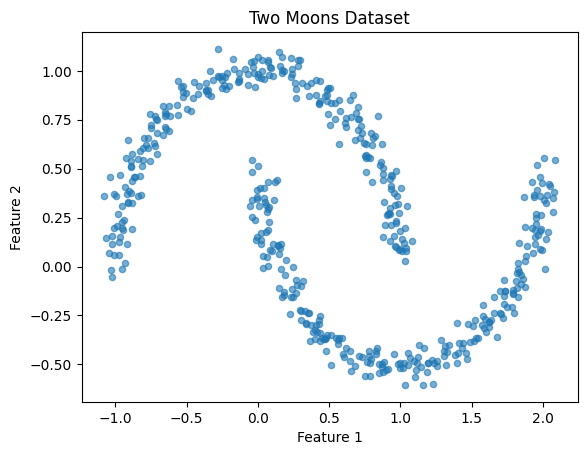

In [2]:
X, y = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

plt.scatter(X[:, 0], X[:, 1], s=20, alpha=0.6)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Two Moons Dataset")
plt.show()

The two-moons dataset contains two curved clusters.

This dataset is difficult for centroid-based algorithms like K-Means.

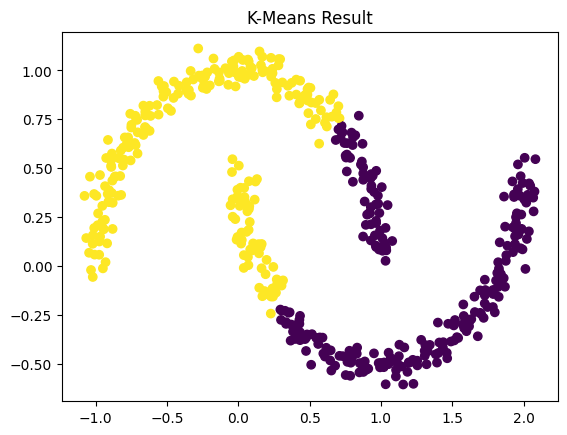

In [3]:
kmeans = KMeans(n_clusters=2, random_state=42)

labels_kmeans = kmeans.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels_kmeans, cmap="viridis")
plt.title("K-Means Result")
plt.show()

K-Means partitions the data using centroid distance.

Because the clusters are curved, K-Means splits the moons incorrectly.

In [4]:
dbscan = DBSCAN(eps=0.2, min_samples=5)

labels_dbscan = dbscan.fit_predict(X)

In [5]:
noise_points = np.sum(labels_dbscan == -1)

print("Number of noise points:", noise_points)

Number of noise points: 0


## DBSCAN Parameters

eps:
    Radius defining neighborhood distance.

min_samples:
    Minimum number of neighbors required to form a dense region.

Choosing these parameters determines the clustering structure.

## Key Takeaways

• DBSCAN defines clusters using density rather than centroids.

• It can discover clusters of arbitrary shape.

• DBSCAN automatically detects noise points.

• Unlike K-Means, it does not require specifying the number of clusters.

However, DBSCAN is sensitive to the choice of ε (epsilon).